In [ ]:
#DMR volcona plots and annotations.

In [8]:
## New DMRs result

dmr <- readRDS("data/LOY_ROY_corrected_bsseq_DMR0.2.rds") # Can be provided up

In [9]:
head(dmr)

,chr,start,end,length,nCG,meanMethy1,meanMethy2,diff.Methy,areaStat
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
46456,chr19,1749175,1750852,1678,128,0.10048419,0.4634073,-0.3629231,-1784.279
32854,chr14,73536782,73538187,1406,103,0.12386702,0.5043971,-0.3805301,-1755.085
41141,chr17,41527526,41528525,1000,97,0.42190325,0.7515394,-0.3296362,-1590.537
15539,chr11,6319052,6320904,1853,122,0.21233734,0.6683840,-0.4560467,-1551.228
71801,chr4,8269468,8270224,757,95,0.33120478,0.6692841,-0.3380793,-1328.750
14025,chr10,102230456,102231392,937,103,0.05437822,0.3565085,-0.3021303,-1327.453


In [10]:
library(dplyr)

In [11]:
delta_cutoff <- 0.2   # adjust if needed

dmr_volcano <- dmr %>%
  mutate(
    diff = diff.Methy,
    areaStat_abs = abs(areaStat),
    category = case_when(
      diff >=  delta_cutoff ~ "Hypermethylated",
      diff <= -delta_cutoff ~ "Hypomethylated",
      TRUE                  ~ "Not Significant"
    )
  )

In [12]:
n_hyper_dmr <- sum(dmr_volcano$category == "Hypermethylated")
n_hypo_dmr  <- sum(dmr_volcano$category == "Hypomethylated")

In [13]:
library(ggplot2)

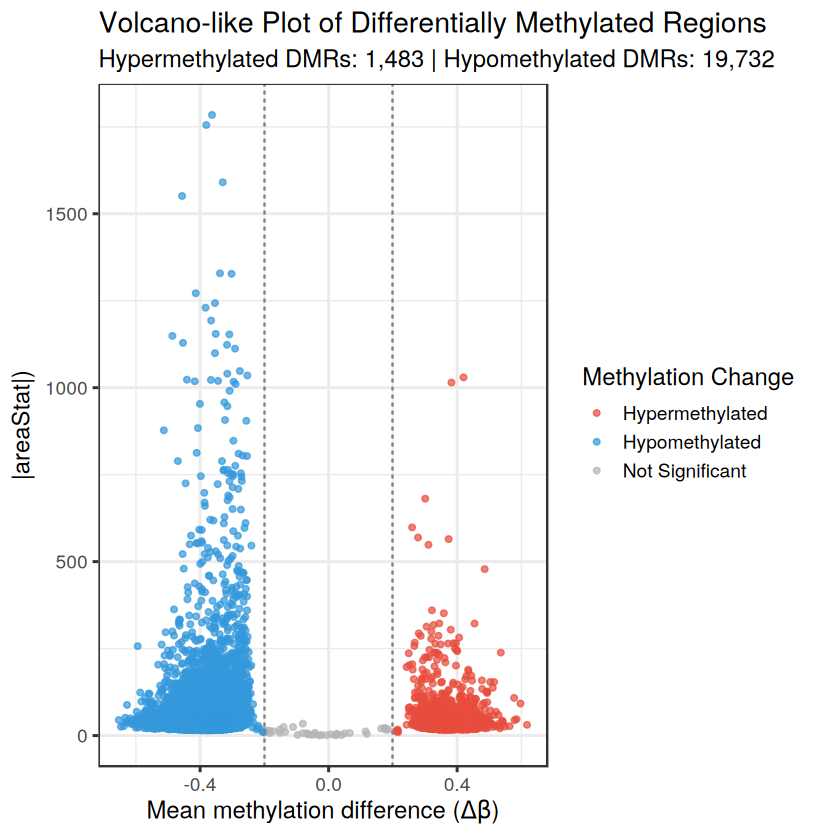

In [14]:
p_dmr_volcano <- ggplot(
  dmr_volcano,
  aes(x = diff, y = areaStat_abs, color = category)
) +
  geom_point(alpha = 0.7, size = 1.2) +
  scale_color_manual(
    values = c(
      "Not Significant" = "gray70",
      "Hypermethylated" = "#E74C3C",
      "Hypomethylated"  = "#3498DB"
    ),
    name = "Methylation Change"
  ) +
  geom_vline(
    xintercept = c(-delta_cutoff, delta_cutoff),
    linetype = "dashed",
    color = "gray50"
  ) +
  labs(
    title = "Volcano-like Plot of Differentially Methylated Regions",
    subtitle = sprintf(
      "Hypermethylated DMRs: %s | Hypomethylated DMRs: %s",
      format(n_hyper_dmr, big.mark = ","),
      format(n_hypo_dmr,  big.mark = ",")
    ),
    x = expression("Mean methylation difference (" * Delta * beta * ")"),
    y = "|areaStat|)"
  ) +
  theme_bw(base_size = 14)

p_dmr_volcano
